In [2]:
import pandas as pd
df = pd.read_csv("h2.csv")

In [2]:
df.shape

(79330, 31)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79330 entries, 0 to 79329
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   79330 non-null  int64  
 1   LeadTime                     79330 non-null  int64  
 2   ArrivalDateYear              79330 non-null  int64  
 3   ArrivalDateMonth             79330 non-null  object 
 4   ArrivalDateWeekNumber        79330 non-null  int64  
 5   ArrivalDateDayOfMonth        79330 non-null  int64  
 6   StaysInWeekendNights         79330 non-null  int64  
 7   StaysInWeekNights            79330 non-null  int64  
 8   Adults                       79330 non-null  int64  
 9   Children                     79326 non-null  float64
 10  Babies                       79330 non-null  int64  
 11  Meal                         79330 non-null  object 
 12  Country                      79306 non-null  object 
 13  MarketSegment   

In [3]:
df.isnull().sum()[df.isnull().sum() > 0]

Children     4
Country     24
dtype: int64

In [4]:
df["Country"] = df["Country"].fillna(df["Country"].mode()[0])
df["Children"] = df["Children"].fillna(df["Children"].mean())

In [5]:
threshold = 0.0001 * len(df)  

agent_counts = df["Agent"].value_counts()
rare_agents = agent_counts[agent_counts < threshold].index
df["Agent"] = df["Agent"].replace(rare_agents, "Other")
print(rare_agents.shape)
 
country_counts = df["Country"].value_counts()
rare_agents = country_counts[country_counts < threshold].index
df["Country"] = df["Country"].replace(rare_agents, "Other")
print(rare_agents.shape)

Company_counts = df["Company"].value_counts()
rare_agents = Company_counts[Company_counts < threshold].index
df["Company"] = df["Company"].replace(rare_agents, "Other")
print(rare_agents.shape)

(66,)
(49,)
(120,)


In [6]:
df["DepositType"] = df["DepositType"].str.strip()

In [7]:
print(df["DepositType"].unique())
print(df["CustomerType"].unique())

['No Deposit' 'Non Refund' 'Refundable']
['Transient' 'Transient-Party' 'Contract' 'Group']


In [8]:
df.drop(["ReservationStatus", "ReservationStatusDate"], axis=1, inplace=True)

In [ ]:
subset = df[
    (df["Adults"] == 0) &
    ((df["Children"] > 0) | (df["Babies"] > 0))
]

cancelled = (subset["IsCanceled"] == 1).sum()
total = len(subset)

print("Cancelled:", cancelled)
print("Total:", total)
print("Cancellation Percentage:", round(cancelled / total * 100, 2), "%")

In [9]:
df = df[~(
    (df["Adults"] == 0) &
    (df["Children"] == 0) &
    (df["Babies"] == 0)
)]

df = df[df["Adults"] > 0]

In [10]:
df.shape

(78940, 29)

In [11]:
df["TotalNights"] = (
    df["StaysInWeekendNights"] +
    df["StaysInWeekNights"]
)

df["TotalGuests"] = (
    df["Adults"] +
    df["Children"] +
    df["Babies"]
)

df["HasChildren"] = (df["Children"] + df["Babies"] > 0).astype(int)

df["LeadTimePerNight"] = df["LeadTime"] / (df["TotalNights"] + 1)

df["TotalPreviousBookings"] = (
    df["PreviousBookingsNotCanceled"] +
    df["PreviousCancellations"]
)

df["RoomChanged"] = (
    df["ReservedRoomType"] != df["AssignedRoomType"]
).astype(int)

df["ADRPerNight"] = df["ADR"] / (df["TotalNights"] + 1)

df["PreviousCancellationRate"] = (
    df["PreviousCancellations"] /
    (df["PreviousCancellations"] + df["PreviousBookingsNotCanceled"] + 1)
)

df["HadMeal"] = (~df["Meal"].isin(["SC", "Undefined"])).astype(int)

df["ADR_per_Guest"] = df["ADR"] / (df["TotalGuests"] + 1)

df["ADR_per_Night"] = df["ADR"] / (df["TotalNights"] + 1)

df["LeadTime_x_PreviousCancels"] = df["LeadTime"] * df["PreviousCancellationRate"]

df["Guests_per_Night"] = df["TotalGuests"] / (df["TotalNights"] + 1)

df["LeadTimeBin"] = pd.cut(
    df["LeadTime"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", "365+"]
)

df["ADR_Bin"] = pd.cut(
    df["ADR"],
    bins=[-1, 50, 100, 150, 250, float("inf")],
    labels=["Very Low", "Low", "Medium", "High", "Luxury"]
)

df["Nights_Bin"] = pd.cut(
    df["TotalNights"],
    bins=[0, 1, 3, 7, 14, float("inf")],
    labels=["1", "2-3", "4-7", "8-14", "15+"]
)

df["Guests_Bin"] = pd.cut(
    df["TotalGuests"],
    bins=[0, 1, 2, 4, float("inf")],
    labels=["1", "2", "3-4", "5+"]
)

df["PrevCancel_Bin"] = pd.cut(
    df["PreviousCancellationRate"],
    bins=[-0.01, 0, 0.25, 0.5, 0.75, 1],
    labels=["0", "Low", "Medium", "High", "Very High"]
)

df["BookingChanges_Bin"] = pd.cut(
    df["BookingChanges"],
    bins=[-1, 0, 1, 3, float("inf")],
    labels=["0", "1", "2-3", "4+"]
)

df["SpecialReq_Bin"] = pd.cut(
    df["SpecialRequests"],
    bins=[-1, 0, 1, 2, 5],
    labels=["0", "1", "2", "3+"]
)

df["WaitingList_Bin"] = pd.cut(
    df["DaysInWaitingList"],
    bins=[-1, 0, 30, 90, float("inf")],
    labels=["0", "1-30", "31-90", "90+"]
)

season_map = {
    "January": "Winter",
    "February": "Winter",
    "March": "Spring",
    "April": "Spring",
    "May": "Spring",
    "June": "Summer",
    "July": "Summer",
    "August": "Summer",
    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn",
    "December": "Winter"
}
df["Season"] = df["ArrivalDateMonth"].map(season_map)

df["ParkingPerGuest"] = df["RequiredCarParkingSpaces"] / (df["TotalGuests"] + 1)

df["HasParking"] = (df["RequiredCarParkingSpaces"] > 0).astype(int)



In [12]:
df.shape

(78940, 38)

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)
print(cat_cols.shape)

['IsCanceled', 'LeadTime', 'ArrivalDateYear', 'ArrivalDateWeekNumber', 'ArrivalDateDayOfMonth', 'StaysInWeekendNights', 'StaysInWeekNights', 'Adults', 'Children', 'Babies', 'IsRepeatedGuest', 'PreviousCancellations', 'PreviousBookingsNotCanceled', 'BookingChanges', 'DaysInWaitingList', 'ADR', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests', 'TotalNights', 'TotalGuests', 'HasChildren', 'LeadTimePerNight', 'TotalPreviousBookings', 'RoomChanged', 'ADRPerNight', 'PreviousCancellationRate', 'HadMeal']
['ArrivalDateMonth', 'Meal', 'Country', 'MarketSegment', 'DistributionChannel', 'ReservedRoomType', 'AssignedRoomType', 'DepositType', 'Agent', 'Company', 'CustomerType']


In [14]:
ohe_cols = [
    "ArrivalDateMonth",
    "Meal",
    "Country",
    "MarketSegment",
    "DistributionChannel",
    "ReservedRoomType",
    "AssignedRoomType",
    "Agent",
    "Company"
]
ordinal_cols = [
    "DepositType",
    "CustomerType"
]
deposit_order = ["No Deposit", "Refundable", "Non Refund"]
customer_order = ["Transient", "Contract", "Transient-Party", "Group"]

In [15]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_df = pd.DataFrame(
    ohe.fit_transform(df[ohe_cols]),
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df.index
)
df = pd.concat([df.drop(columns=ohe_cols), ohe_df], axis=1)

In [16]:
deposit_order = ["No Deposit", "Refundable", "Non Refund"]
customer_order = ["Transient", "Contract", "Transient-Party", "Group"]

ord_enc = OrdinalEncoder(categories=[deposit_order, customer_order])

df[["DepositType", "CustomerType"]] = ord_enc.fit_transform(
    df[["DepositType", "CustomerType"]]
)

In [17]:
df.shape

(78940, 438)

In [18]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop("IsCanceled", axis=1)
y = df["IsCanceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8730048137826197

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.89      9189
           1       0.88      0.81      0.84      6599

    accuracy                           0.87     15788
   macro avg       0.87      0.86      0.87     15788
weighted avg       0.87      0.87      0.87     15788


Confusion Matrix:
 [[8445  744]
 [1261 5338]]


In [21]:
from xgboost import XGBClassifier

xgb_cv = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    xgb_cv,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.87053458 0.86901444 0.86819103 0.86819103 0.87091462]
0.869369141119838


In [20]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

low_features = importance[importance["Importance"] < 0.005]["Feature"]

X_new = X.drop(columns=low_features)

print(low_features)

52                           Country_BEL
182    AssignedRoomType_A               
29               ArrivalDateMonth_August
79                           Country_ESP
297                    Agent_        195
                     ...                
236                    Agent_         55
238                    Agent_         57
240                    Agent_         60
242                    Agent_         64
436                        Company_Other
Name: Feature, Length: 408, dtype: object


In [22]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = 0
best_params = None

for n_estimators in [200,700, 500]:
    for max_depth in [5, 7, 9]:
        for learning_rate in [0.01, 0.1]:

            xgb = XGBClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )

            score = cross_val_score(
                xgb,
                X,
                y,
                cv=skf,
                scoring="accuracy",
                n_jobs=-1
            ).mean()

            print(f"{n_estimators=}, {max_depth=}, {learning_rate=}: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = (n_estimators, max_depth, learning_rate)

print("\nBest CV Accuracy:", best_score)
print("Best Parameters:", best_params)

n_estimators=200, max_depth=5, learning_rate=0.01: 0.8404
n_estimators=200, max_depth=5, learning_rate=0.1: 0.8680
n_estimators=200, max_depth=7, learning_rate=0.01: 0.8510
n_estimators=200, max_depth=7, learning_rate=0.1: 0.8755
n_estimators=200, max_depth=9, learning_rate=0.01: 0.8597
n_estimators=200, max_depth=9, learning_rate=0.1: 0.8823
n_estimators=700, max_depth=5, learning_rate=0.01: 0.8543
n_estimators=700, max_depth=5, learning_rate=0.1: 0.8793
n_estimators=700, max_depth=7, learning_rate=0.01: 0.8642
n_estimators=700, max_depth=7, learning_rate=0.1: 0.8868
n_estimators=700, max_depth=9, learning_rate=0.01: 0.8715
n_estimators=700, max_depth=9, learning_rate=0.1: 0.8907
n_estimators=500, max_depth=5, learning_rate=0.01: 0.8499
n_estimators=500, max_depth=5, learning_rate=0.1: 0.8768
n_estimators=500, max_depth=7, learning_rate=0.01: 0.8596
n_estimators=500, max_depth=7, learning_rate=0.1: 0.8840
n_estimators=500, max_depth=9, learning_rate=0.01: 0.8682
n_estimators=500, max_

In [23]:
xgb = XGBClassifier(
    n_estimators=700,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.8912465163415252


In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    xgb_cv,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.87053458 0.86901444 0.86819103 0.86819103 0.87091462]
0.869369141119838


In [25]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=700,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb.fit(X_train, y_train)

# Test Accuracy
y_pred = xgb.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Test Accuracy: 0.8912465163415252
CV Scores: [0.89346339 0.89010641 0.88921966 0.89016975 0.89042311]
Mean CV Accuracy: 0.8906764631365593


Accuracy : 0.8912465163415252
Precision: 0.8822424052615095
Recall   : 0.8537657220791028
F1 Score : 0.8677705044281864
ROC-AUC  : 0.9605578320903959

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      9189
           1       0.88      0.85      0.87      6599

    accuracy                           0.89     15788
   macro avg       0.89      0.89      0.89     15788
weighted avg       0.89      0.89      0.89     15788


Confusion Matrix:

[[8437  752]
 [ 965 5634]]

CV Scores: [0.89346339 0.89010641 0.88921966 0.89016975 0.89042311]
Mean CV Accuracy: 0.8906764631365593


<Figure size 1000x800 with 0 Axes>

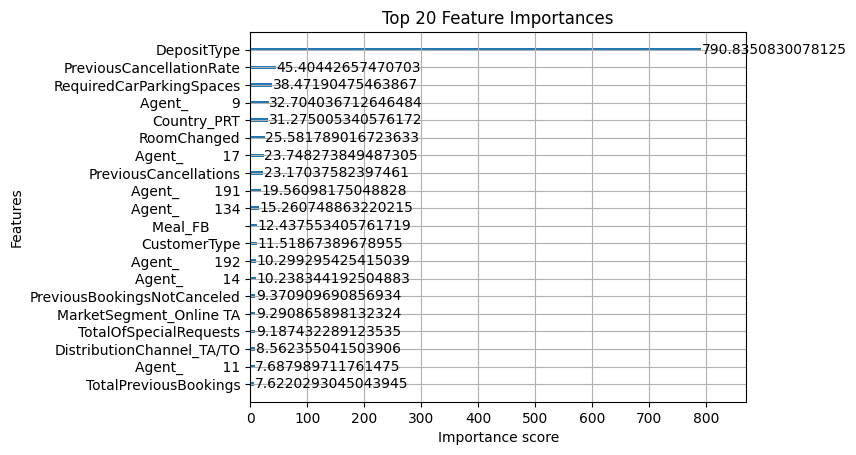

In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Model
xgb = XGBClassifier(
    n_estimators=700,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# Feature Importance Plot
plt.figure(figsize=(10,8))
plot_importance(
    xgb,
    max_num_features=20,
    importance_type="gain"
)
plt.title("Top 20 Feature Importances")
plt.show()

In [3]:
country_cancelled = pd.crosstab(df["Country"], df["IsCanceled"])
country_cancelled

IsCanceled,0,1
Country,,
ABW,2,0
AGO,140,198
AIA,1,0
ALB,8,1
AND,0,2
...,...,...
VGB,0,1
VNM,4,2
ZAF,36,26


In [4]:
country_cancelled.sort_values(by=0, ascending=False)

IsCanceled,0,1
Country,,
PRT,10879,20081
FRA,7081,1723
DEU,5012,1072
GBR,3753,1562
ESP,3285,1326
...,...,...
GLP,0,2
MAC,0,15
HND,0,1


In [5]:
country_cancelled.sort_values(by=1, ascending=False)

IsCanceled,0,1
Country,,
PRT,10879,20081
FRA,7081,1723
GBR,3753,1562
ESP,3285,1326
ITA,2054,1253
...,...,...
NCL,1,0
PAN,9,0
PRY,4,0


In [6]:
country_cancel_percentage = (
    df.groupby("Country")["IsCanceled"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

country_cancel_percentage

Country
ZWE    100.0
MAC    100.0
GGY    100.0
GIB    100.0
GLP    100.0
       ...  
NCL      0.0
PAN      0.0
PRY      0.0
PYF      0.0
KIR      0.0
Name: IsCanceled, Length: 166, dtype: float64

In [7]:
country_summary = pd.DataFrame({
    "Total_Bookings": df["Country"].value_counts(),
    "Cancel_Percentage": (
        df.groupby("Country")["IsCanceled"]
          .mean()
          .mul(100)
          .round(2)
    )
}).reset_index()

country_summary.rename(columns={"index": "Country"}, inplace=True)

print(country_summary)

    Country  Total_Bookings  Cancel_Percentage
0       ABW               2               0.00
1       AGO             338              58.58
2       AIA               1               0.00
3       ALB               9              11.11
4       AND               2             100.00
..      ...             ...                ...
161     VGB               1             100.00
162     VNM               6              33.33
163     ZAF              62              41.94
164     ZMB               1             100.00
165     ZWE               2             100.00

[166 rows x 3 columns]


In [8]:
country_summary = country_summary.sort_values(
    by="Total_Bookings", ascending=False
)

print(country_summary)

    Country  Total_Bookings  Cancel_Percentage
125     PRT           30960              64.86
50      FRA            8804              19.57
39      DEU            6084              17.62
53      GBR            5315              29.39
46      ESP            4611              28.76
..      ...             ...                ...
107     MRT               1               0.00
133     SDN               1               0.00
111     NAM               1               0.00
112     NCL               1               0.00
83      KIR               1               0.00

[166 rows x 3 columns]


In [10]:
df["DistributionChannel"].value_counts()

DistributionChannel
TA/TO        68945
Direct        6780
Corporate     3408
GDS            193
Undefined        4
Name: count, dtype: int64

In [11]:
pd.crosstab(df["DistributionChannel"], df["IsCanceled"])

IsCanceled,0,1
DistributionChannel,,
Corporate,2622,786
Direct,5548,1232
GDS,156,37
TA/TO,37902,31043
Undefined,0,4


In [12]:
pd.crosstab(
    df["DistributionChannel"],
    df["IsCanceled"],
    normalize="index"
).mul(100).round(2)

IsCanceled,0,1
DistributionChannel,,
Corporate,76.94,23.06
Direct,81.83,18.17
GDS,80.83,19.17
TA/TO,54.97,45.03
Undefined,0.00,100.00
